# 1 介绍与快速开始

https://github.com/huggingface/transformers/blob/main/docs/source/zh/quicktour.md

Hugging Face Transformers 是目前最流行的开源 NLP / AI 库，提供数千个预训练模型，覆盖文本、图像、音频、多模态等几乎所有 AI 任务。

| 核心生态 | 库名称 | 主要功能/特点 |
| :--- | :--- | :--- |
| **模型框架** | **Transformers** | 预训练模型推理<br>与微调框架 |
| **数据集** | **Datasets** | 海量数据集<br>高效加载处理 |
| **分词器** | **Tokenizers** | 高性能分词器<br>(Rust实现) |
| **评估指标** | **Evaluate** | 模型评估指标<br>(BLEU/F1等) |
| **参数微调** | **PEFT** | 参数高效微调<br>LoRA / QLoRA |
| **分布式训练** | **Accelerate** | 多GPU/TPU训练<br>分布式加速 |

支持的任务类型

| 领域               | 任务                                                                 |
|--------------------|----------------------------------------------------------------------|
| **NLP 自然语言处理** | 文本分类（情感分析）、命名实体识别（NER）、问答系统（QA）、文本摘要生成、机器翻译、文本生成（对话）、填空/语言模型 |
| **CV 计算机视觉**   | 图像分类、目标检测、图像分割、深度估计、图像生成、视频分类、关键点检测 |
| **音频 & 多模态**   | 语音识别（ASR）、音频分类、文本转语音（TTS）、图文匹配（VQA）、图像描述生成、文档问答（DOC QA）、零样本分类 |

## 1.1 Transformer架构

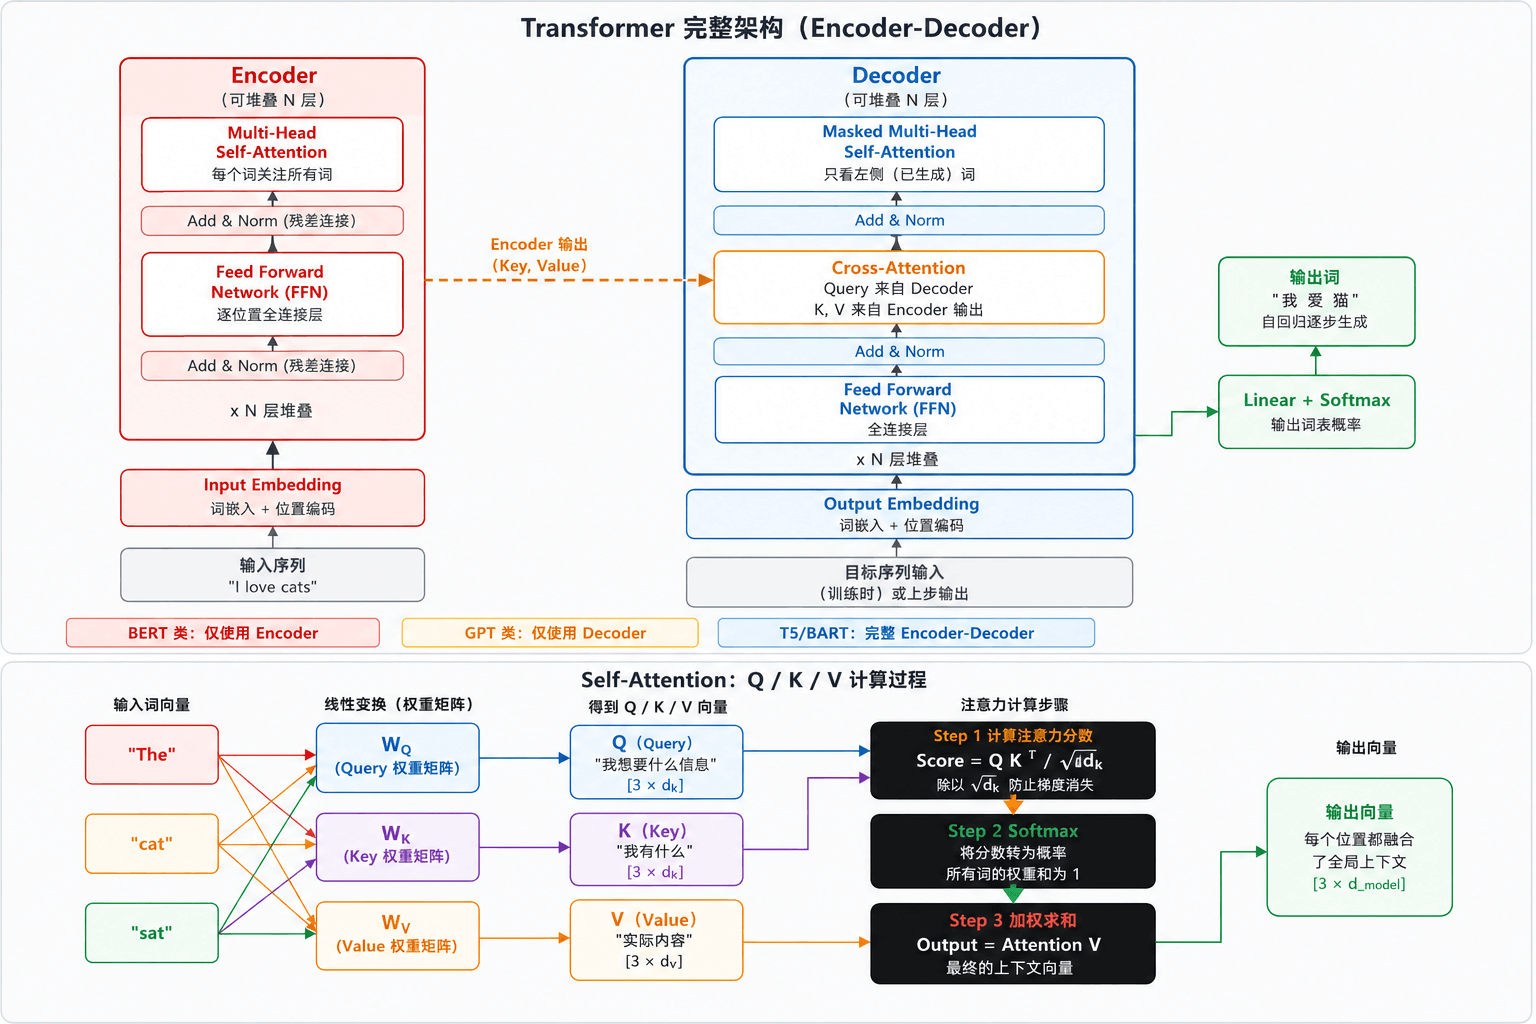

|| 架构 | 适用场景 | 代表模型 |
|------|------|----------|----------|
| **仅 Encoder** | 双向注意力，可同时看到全部输入；`[CLS]` 表示全局，`[MASK]` 做预训练 | 分类、NER、问答（理解类） | BERT、RoBERTa、ALBERT、BERT-wwm、MacBERT |
| **仅 Decoder** | 因果注意力（只看左侧），自回归生成；逐词预测下一词，循环拼接 | 文本生成、对话、代码生成 | GPT 系列、LLaMA、Qwen |
| **Encoder-Decoder** | 序列到序列（Seq2Seq）；编码输入 → 解码生成输出 | 翻译、摘要、问答生成 | T5、BART、mT5、PEGASUS-Chinese |

## 1.2 Pipeline
Pipeline 是 Transformers 最高级别的抽象，把模型加载、预处理、推理、后处理全部封装好，三到五行代码即可完成推理。

```py
from transformers import pipeline
import torch

# 情感分析（文本分类）
classifier = pipeline("sentiment-analysis")
result = classifier("I love using Hugging Face Transformers!")
# 输出 [{'label': 'POSITIVE', 'score': 0.9998}]

# 指定 GPU 与模型
pipe = pipeline("text-generation", model="gpt2", device=0)

# 指定精度（省显存）
pipe = pipeline("text-generation", model="meta-llama/Llama-2-7b-hf",
    torch_dtype=torch.float16, device_map="auto")

# 批量处理（提升吞吐量）
pipe = pipeline("sentiment-analysis", batch_size=32)
results = pipe(large_text_list)    # 自动分批推理

# 大文本分块处理
asr = pipeline("automatic-speech-recognition",
    model="openai/whisper-large-v2",
    chunk_length_s=30, stride_length_s=5)
result = asr("long_audio.wav", return_timestamps=True)
```

## 1.3 Tokenizer
把原始文本转换成模型能理解的数字序列。

```md
Step 1 原始文本：
"Hello, I'm learning Transformers! It's great."

↓

Step 2 分词 (Tokenize)：
["Hello", ",", "I", "'m", "learning", "Transform", "##ers", "!", ...]

说明： WordPiece/BPE 子词分词：罕见词被拆分 (Transformers -> Transform + ##ers)

↓

Step 3 添加特殊标记：
["[CLS]", "Hello", ",", "I", "'m", "learning", "Transform", "##ers", ... "[SEP]"]

说明： [CLS]分类标记 [SEP]分隔符 [PAD]填充；不同模型特殊标记不同

↓

Step 4 转换为 Token IDs：
[101, 7592, 1010, 1045, 1005, 1049, 4083, 19081, 2121, ... 102]

说明： 每个 token 映射到词表中的整数索引，送入模型 Embedding 层
```

主流分词算法

| 算法 | 全称 | 原理 | 示例分词 | 代表模型 |
|------|------|------|----------|----------|
| **BPE** | Byte Pair Encoding | 统计高频字符对，迭代合并，学习最优子词词表 | `"transformers"` → `["transform", "ers"]` | GPT / RoBERTa |
| **WordPiece** | WordPiece | 最大化语言模型概率，使用 `##` 前缀标记子词 | `"transformers"` → `["transform", "##ers"]` | BERT / DistilBERT |
| **SentencePiece** | SentencePiece | Unigram / BPE 变体，语言无关，直接处理原始字节，用 `_` 标记词首 | `"transformers"` → `["_transform", "ers"]` | T5 / LLaMA / Qwen |

```py
from transformers import AutoTokenizer

# 加载 Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

encoding = tokenizer(
    "Hello, I'm learning Transformers!",
    return_tensors="pt",        # 返回 PyTorch tensor
    padding=True,               # 填充到最长序列
    truncation=True,            # 超出长度时截断
    max_length=128,             # 最大长度
)

print(encoding.keys())
# -> dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])

print(encoding["input_ids"][0][:8])
# -> tensor([101, 7592, 1010, 1045, 1005, 1049, 4083, 19081])

print(encoding["attention_mask"][0][:8])
# -> tensor([1, 1, 1, 1, 1, 1, 1, 1])    # 1=真实token, 0=填充

# 解码（ID -> 文本）
decoded = tokenizer.decode(encoding["input_ids"][0], skip_special_tokens=True)
print(decoded)   # -> "hello, i'm learning transformers!"

# 批量编码（自动 padding 对齐）
texts = ["Short.", "This is a much longer sentence for testing."]
batch = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
print(batch["input_ids"].shape)   # -> torch.Size([2, 10])

# 词表信息
print(f"词表大小: {tokenizer.vocab_size}")      # -> 30522
print(f"[CLS] ID: {tokenizer.cls_token_id}")     # -> 101
print(f"[SEP] ID: {tokenizer.sep_token_id}")     # -> 102
print(f"最大长度: {tokenizer.model_max_length}")  # -> 512
```

## 1.4 AutoClass
自动选择正确的模型类

```md
输入模型名称
例如："bert-base-uncased"
或：本地路径

    ↓

AutoClass 处理核心
读取 config.json
匹配架构类型
(AutoModel / AutoTokenizer / ...)

    ↓

自动返回正确的类
BertForSequenceClassification
GPT2LMHeadModel
T5ForConditionalGeneration ...
```


常用 AutoClass 

| 类别 | 名称 | 用途/描述 |
| :--- | :--- | :--- |
| **分词器** | **AutoTokenizer** | 自动分词器 |
| **基础模型** | **AutoModel** | 基础模型（输出隐藏层） |
| **分类任务** | **AutoModelForSeqClass** | 文本分类任务 |
| **生成任务** | **AutoModelForCausalLM** | 文本生成任务 |

```py
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2, torch_dtype=torch.float16, device_map="auto"
)

text = "Transformers is an amazing library!"

# 1. 编码
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

# 2. 前向传播
with torch.no_grad():
    outputs = model(**inputs)

# 3. 解析输出
logits = outputs.logits                       # shape: [1, 2]
probs  = torch.softmax(logits, dim=-1)
pred   = torch.argmax(probs, dim=-1).item()

id2label = model.config.id2label              # {0: 'LABEL_0', 1: 'LABEL_1'}
print(f"预测类别: {id2label[pred]}, 置信度: {probs[0][pred]:.4f}")
```

提取句子向量:
```py
from transformers import AutoModel, AutoTokenizer
import torch

model = AutoModel.from_pretrained("bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def get_sentence_embedding(text: str) -> torch.Tensor:
    inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    # 对所有 token 做均值池化（Mean Pooling）
    token_embeddings = outputs.last_hidden_state          # [1, seq_len, 768]
    attention_mask = inputs["attention_mask"].unsqueeze(-1)
    mean_embedding = (token_embeddings * attention_mask).sum(1) / attention_mask.sum(1)
    return mean_embedding  # [1, 768]

vec = get_sentence_embedding("Hello world")
print(vec.shape)  # -> torch.Size([1, 768])
```

## 1.5 微调（Fine-tuning）
将预训练模型适配到你的特定任务和数据上，是 Transformers 最重要的应用场景。

| 步骤 | 核心操作 | 关键配置/参数 | 技巧与注意事项 |
| :--- | :--- | :--- | :--- |
| **1. 准备数据** | 1. 数据集加载 (HF datasets / 自定义 CSV)<br>2. Tokenize 编码<br>3. Padding 对齐<br>4. DataLoader | - | **关键**： 数据质量 > 数据数量 |
| **2. 加载模型** | 1. `AutoModelForTask`<br>2. 指定 `num_labels`<br>3. 冻结底层参数 | (可选) 只微调顶层 | **技巧**： 小数据集建议先冻结底层 |
| **3. 训练配置** | `TrainingArguments` | • 学习率：2e-5<br>• Batch：32<br>• Epochs：3~5<br>• Warmup 步数<br>• 权重衰减 | **技巧**： 学习率是最重要的超参数 |
| **4. 训练 & 评估** | 1. `Trainer.train()`<br>2. 监控 loss 曲线<br>3. 验证集评估<br>4. Early stopping<br>5. 保存最优 ckpt | - | **注意**： 防止过拟合，需对比基线 |
| **5. 保存** | 1. `save_model()`<br>2. `save_pretrained`<br>3. 推送 Hub | - | **后续**： 生产部署、量化推理、ONNX 导出 |

使用 HuggingFace Trainer 可以大幅简化训练流程，自动处理梯度累积、混合精度、分布式训练等。

示例：文本分类
```py
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
import evaluate, numpy as np

# 1. 加载数据集
dataset = load_dataset("imdb")   # HF Hub 公开数据集

# 2. Tokenizer + 预处理
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512)

tokenized_ds = dataset.map(tokenize_fn, batched=True,
                           remove_columns=["text"])
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format("torch")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. 加载模型
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)

# 4. 评估指标
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
            "f1": f1.compute(predictions=preds, references=labels, average="binary")["f1"]}

# 5. 训练参数
training_args = TrainingArguments(
    output_dir="./results", num_train_epochs=3,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    gradient_accumulation_steps=2, learning_rate=2e-5,
    weight_decay=0.01, warmup_ratio=0.1,
    evaluation_strategy="steps", eval_steps=500,
    save_strategy="steps", save_steps=500,
    load_best_model_at_end=True, metric_for_best_model="f1",
    fp16=True, logging_steps=100, seed=42,
)

# 6. 创建 Trainer 并训练
trainer = Trainer(
    model=model, args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    tokenizer=tokenizer, data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer.train()

# 7. 评估并保存
eval_result = trainer.evaluate()
print(f"准确率: {eval_result['eval_accuracy']:.4f}")
print(f"F1: {eval_result['eval_f1']:.4f}")

trainer.save_model("./my-sentiment-model")
tokenizer.save_pretrained("./my-sentiment-model")
```

### 1.5.1 LoRA 参数高效微调
LoRA 优势：只训练不到 1% 的参数，显存降低 60-70%，速度快 2-3 倍，权重文件仅几 MB，可为同一基础模型保存多个 LoRA 适配器用于不同任务。

| 特性 | 全量微调 (Full Fine-tuning) | LoRA 微调 |
| :--- | :--- | :--- |
| **核心公式** | $$W + \Delta W$$ | $$W (\text{冻结}) + B \times A$$ |
| **更新策略** | 更新全部权重矩阵 | 仅训练低秩矩阵 ($r \ll d$) |
| **参数量** | 全部 (如 7B 参数全训) | 原来的 **0.1% ~ 1%** |
| **显存需求** | 极高 (需 4x 模型大小) | 低 (只存低秩矩阵梯度) |
| **成本/硬件** | 昂贵，需要大量 GPU | **单卡 24GB 可微调 7B** |

LoRA 将 $\Delta W$ 分解为两个低秩矩阵，$r$ 远小于 $d$（通常 $r=8 \sim 64$），大幅降低训练成本。

```py
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
import torch

model_name = "meta-llama/Llama-2-7b-hf"
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float16, device_map="auto",
    load_in_4bit=True,        # 4-bit 量化加载（QLoRA），进一步省显存
)

# 配置 LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# -> trainable: 4,194,304 || all: 6,742,609,920 || 0.0622%
```

## 1.6 模型保存、加载与发布
```py
# 本地保存
model.save_pretrained("./my-model")
tokenizer.save_pretrained("./my-model")

# 本地加载
model = AutoModelForSequenceClassification.from_pretrained("./my-model")
tokenizer = AutoTokenizer.from_pretrained("./my-model")

# 发布到 HuggingFace Hub
from huggingface_hub import login
login(token="your_hf_token")   # huggingface.co/settings/tokens
model.push_to_hub("your-username/my-sentiment-model")
tokenizer.push_to_hub("your-username/my-sentiment-model")

# 通过 Trainer 直接发布
training_args = TrainingArguments(
    output_dir="your-username/my-model",
    push_to_hub=True, hub_strategy="every_save",
)
```

## 1.7 性能优化

| 层级 | 核心技术 / 方法 | 加速效果 / 收益 |
| :--- | :--- | :--- |
| **1 - 零成本优化** | • `torch.no_grad()` 推理<br>• `fp16` / `bf16` 半精度<br>• `batch` 推理<br>• `device_map="auto"` 自动分配设备 | **加速：1.5 ~ 2x**<br>*(无需修改模型，代码层面优化)* |
| **2 - 量化（模型压缩）** | • `bitsandbytes` 4-bit / 8-bit 量化<br>• `GPTQ`（后训练量化）<br>• `AWQ`（激活感知量化） | **加速：2 ~ 4x**<br>**显存减半** |
| **3 - 编译与运行时优化** | • `torch.compile()` (PyTorch 2.0)<br>• `FlashAttention-2`<br>• `xFormers`<br>• `Optimum` (TensorRT / ONNX) | **加速：3 ~ 10x**<br>*(通过底层算子融合优化)* |
| **4 - 专用推理引擎** | • `vLLM`（LLM 高吞吐推理）<br>• `TGI`<br>• `TensorRT-LLM`<br>• `llama.cpp`（CPU 推理） | **生产级，最高性能**<br>*(工程化部署方案)* |

```py
# 4-bit 量化加载（13B 模型只需约 7GB 显存）
from transformers import BitsAndBytesConfig, AutoModelForCausalLM
import torch

quant_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4",
)
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-13b-hf",
    quantization_config=quant_config, device_map="auto",
)

# FlashAttention-2 加速（需 pip install flash-attn）
model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.1",
    attn_implementation="flash_attention_2",
    torch_dtype=torch.bfloat16, device_map="auto",
)

# torch.compile (PyTorch 2.0+)
model = torch.compile(model, mode="reduce-overhead")
```

## 1.8 常见问题

| 错误信息 | 原因与解决方案 |
| :--- | :--- |
| **CUDA out of memory** | **显存不足**<br>• 减小 `batch_size`<br>• 加 `gradient_accumulation_steps`<br>• 用 `fp16` / `4-bit`<br>• 用更小模型 |
| **OSError: model not found** | **模型名称错误或网络问题**<br>• 检查拼写<br>• 设置 `HF_ENDPOINT` 镜像<br>• 已下载则用本地路径 |
| **ValueError: num_labels mismatch** | 加载模型时显式指定 `num_labels=你的类别数` |
| **tensors on different devices** | `inputs = {k: v.to(model.device) for k, v in inputs.items()}` |
| **loss = NaN / loss 不下降** | • 检查学习率（太大会 NaN）<br>• 检查 labels 值域（0~N-1）<br>• 加 `gradient_clipping` |
| **slow tokenizer / 速度慢** | • `pip install tokenizers` 安装 Rust 快速版本<br>• 使用 `use_fast=True`（默认） |

## 1.9 API
```py
# 1. 加载分词器
tokenizer = AutoTokenizer.from_pretrained("model_name")

# 2. 编码文本
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

# 3. 加载模型
model = AutoModelForSequenceClassification.from_pretrained("model_name", num_labels=N)

# 4. 推理
with torch.no_grad():
    outputs = model(**inputs)

# 5. Pipeline
pipe = pipeline("task_name", model="model_name")

# 6. 训练配置
args = TrainingArguments(output_dir="./out", num_train_epochs=3, learning_rate=2e-5)

# 7. 训练
trainer = Trainer(model=model, args=args, train_dataset=ds, compute_metrics=fn)

# 8. 保存
model.save_pretrained("./my-model")
tokenizer.save_pretrained("./my-model")

# 9. 数据集
dataset = load_dataset("dataset_name")
dataset = dataset.map(tokenize_fn, batched=True)

# 10. LoRA
config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj","v_proj"])
model = get_peft_model(model, config)
```

# 2 安装
```bash
# 基础安装
pip install transformers

# 完整安装（包含训练依赖）
pip install transformers[torch]       # PyTorch 后端

# 常用配套库
pip install datasets          # HuggingFace 数据集库
pip install evaluate          # 模型评估指标
pip install accelerate        # 多GPU/混合精度训练（节省显存）
pip install peft              # 做微调：参数高效微调（LoRA/QLoRA等）
pip install tokenizers        # 高性能分词器（安装 transformers时自动安装好了）
pip install sentencepiece     # 做推理对话：部分模型（T5/LLaMA）的分词器底层依赖
```

In [1]:
import sys

def check_environment():
    print("=" * 50)
    print("环境检测")
    print("=" * 50)

    # 1. 检测 PyTorch
    print("\n[1/3] 检测 PyTorch...")
    try:
        import torch
        print(f"PyTorch 安装成功！版本: {torch.__version__}")
    except ImportError:
        print("PyTorch 未安装！请运行: pip install torch")
        return

    # 2. 检测 CUDA 和 GPU
    print("\n[2/3] 检测 CUDA 与 GPU...")
    if torch.cuda.is_available():
        print(f"CUDA 可用！CUDA 版本: {torch.version.cuda}")
        print(f"检测到 GPU 数量: {torch.cuda.device_count()}")
        
        for i in range(torch.cuda.device_count()):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_mem = torch.cuda.get_device_properties(i).total_memory / (1024**3)
            print(f"   GPU {i}: {gpu_name} (显存: {gpu_mem:.2f} GB)")
            
        # 实际在 GPU 上进行一个简单的计算测试
        try:
            test_tensor = torch.tensor([1.0, 2.0]).cuda()
            result = test_tensor * 2
            print(f"GPU 计算测试通过！测试结果: {result.tolist()}")
        except Exception as e:
            print(f"GPU 计算测试失败: {e}")
    else:
        print("CUDA 不可用，PyTorch 将使用 CPU 运行。")
        print("   (如果你有 NVIDIA 显卡，请检查是否安装了支持 CUDA 的 PyTorch 版本)")

    # 3. 检测 Transformers
    print("\n[3/3] 检测 Transformers...")
    try:
        import transformers
        print(f"Transformers 安装成功！版本: {transformers.__version__}")
    except ImportError:
        print("Transformers 未安装！请运行: pip install transformers")
        return

    # 4. 综合结果
    print("\n" + "=" * 50)
    if torch.cuda.is_available():
        print("环境检测完毕！所有组件均正常，可以使用 GPU 加速训练！")
    else:
        print("环境检测完毕！基础库已安装，但仅支持 CPU 运行。")
    print("=" * 50)

if __name__ == "__main__":
    check_environment()


环境检测

[1/3] 检测 PyTorch...
PyTorch 安装成功！版本: 2.5.1

[2/3] 检测 CUDA 与 GPU...
CUDA 可用！CUDA 版本: 12.1
检测到 GPU 数量: 1
   GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU (显存: 8.00 GB)
GPU 计算测试通过！测试结果: [2.0, 4.0]

[3/3] 检测 Transformers...


d:\Miniconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers 安装成功！版本: 5.3.0

环境检测完毕！所有组件均正常，可以使用 GPU 加速训练！


## 2.1 配置
下载加速：

```bash
使用镜像站加速下载（如 hf-mirror.com）
export HF_ENDPOINT=https://hf-mirror.com
```

```py
# 也可以在代码中设置
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
```

模型位置：

C:\Users\你的用户名\\.cache\huggingface\hub\

文件结构：
```md
hub/
└── models--distilbert-base-uncased-finetuned-sst-2-english/             
    ├── blobs/          ← 实际的文件内容（按哈希命名）
    ├── refs/           ← 版本指针（如 main）
    └── snapshots/      ← 某个版本的完整文件名映射
        └── <一串哈希>/
            ├── config.json             ← 模型结构配置（层数、隐藏维度与激活函数等）
            ├── tokenizer.json          ← 分词器核心逻辑
            ├── tokenizer_config.json   ← 分词器配置（如特殊 token）
            ├── vocab.txt               ← 词表文件（每个 token 对应一个编号）
            └── model.safetensors       ← 模型权重与参数（最重要的，体积最大）
```

# 3 核心概念

## 3.1 预训练模型

常见的预训练模型：
- BERT（Bidirectional Encoder Representations from Transformers）：  
基于 Transformer 架构的预训练模型，特点是双向编码。在预训练阶段，BERT 通过两个无监督任务来学习语言知识。一个是掩码语言模型（MLM），简单说就是随机将输入文本中的一些词用特殊标记 `[MASK]` 替代，让模型去预测这些被掩码的词。比如句子 “I love [MASK]”，模型要预测出合适的词，像 “you”“reading” 等。另一个任务是下一句预测（Next Sentence Prediction，NSP），判断两个句子在原文中是否相邻。这种双向编码方式使得 BERT 能同时考虑到上下文信息，在自然语言理解任务（如文本分类、命名实体识别、问答系统等）中表现出色。

- GPT（Generative Pretrained Transformer）：  
采用自左向右的单向语言模型架构。它的预训练过程主要是基于语言建模，根据前文预测下一个词。例如给定前文 “I am going to”，模型预测出后续可能的词，如 “school”“play” 等。GPT 系列模型在语言生成方面优势明显，像文本续写、对话生成等任务，生成的文本流畅自然，符合语言习惯。随着 GPT 版本的不断升级，模型规模和性能也在不断提升，如 GPT - 3 拥有 1750 亿参数，具备很强的零样本和少样本学习能力，GPT - 4 更是在复杂推理、理解等方面有显著进步。

预训练模型的优势：
- **迁移学习能力**：预训练模型在大规模无标注数据上进行训练，学习到了通用的语言特征和知识。当我们面对特定的下游任务（如情感分析、机器翻译等）时，可以将这些预训练的权重作为初始化，然后在下游任务的少量有标注数据上进行微调。这样大大减少了从随机初始化开始训练模型所需的计算资源和时间，因为模型已经具备了一定的语言理解基础，只需要针对具体任务进行调整。

- **数据利用效率高**：对于许多自然语言处理任务，获取大规模有标注数据成本高昂。预训练模型通过在海量无标注数据上学习，能有效利用这些数据中的信息。然后在微调阶段，仅需相对少量的有标注数据，就可以适应各种不同的具体任务，提高了数据的利用效率。

- **性能提升显著**：在众多自然语言处理任务上，基于预训练模型微调后的性能比传统从头开始训练的模型有大幅提升。这是因为预训练模型在大规模数据上学习到了丰富的语义、语法等语言知识，这些知识能够帮助模型更好地理解和处理输入文本，从而在各种任务中表现更优。例如在文本分类任务中，使用预训练模型微调后的准确率可能比传统方法提高 10% - 20% 甚至更多。

## 3.2 Tokenizer（分词器）
 - **分词原理**：
    - **基于字典的分词**：这是一种较为基础的方法，分词器会维护一个庞大的词典。在对文本进行分词时，从文本的开头开始，按顺序匹配词典中的词汇。例如，对于句子“我喜欢自然语言处理”，如果词典中有“我”“喜欢”“自然语言处理”等词，分词器就会将其分成这些对应的词。这种方法简单直接，但对于未登录词（即词典中没有的词）处理能力较差。
    - **基于统计的分词**：这类方法主要依据词在语料库中的统计信息来进行分词。常见的统计指标有词频、相邻字的共现频率等。例如，两个字经常一起出现，那么它们组成一个词的可能性就较大。隐马尔可夫模型（HMM）和最大熵马尔可夫模型（MEMM）等统计模型常被用于这种分词方式。以HMM为例，它把分词看作是一个状态序列的生成过程，每个字对应一个状态，通过计算状态转移概率和观测概率来确定最优的分词结果。
    - **基于神经网络的分词**：随着深度学习的发展，基于神经网络的分词方法逐渐流行。例如，利用循环神经网络（RNN）或其变体长短期记忆网络（LSTM）、门控循环单元（GRU），以及卷积神经网络（CNN）来对文本进行建模。这些模型可以自动学习文本中的特征模式，从而更好地处理分词任务。在一些模型中，会将文本中的每个字符作为输入，模型输出每个字符属于词首、词中、词尾等不同位置的概率，进而确定分词结果。

 - **不同Tokenizer特点（如BertTokenizer、GPT2Tokenizer等）**：
    - **BertTokenizer**：
        - **词汇表构建**：BertTokenizer使用WordPiece分词算法构建词汇表。它从单个字符开始，根据词频逐步合并成子词。例如，“unhappiness”可能会被分成“un”“happi”“ness”。这种方式能够有效处理未登录词，同时词汇表相对较小，减少了模型的参数。
        - **特殊标记**：BertTokenizer有一些特殊标记，如[CLS]（Classification Token）用于表示句子的开始，一般在文本分类等任务中，模型会将[CLS]标记对应的输出作为整个句子的特征表示；[SEP]（Separator Token）用于分隔不同的句子，在处理多个句子输入时很有用，比如问答任务中区分问题和答案。
        - **应用场景**：由于BERT主要用于自然语言理解任务，BertTokenizer的设计也更适合这类任务，能很好地处理上下文信息，为模型提供准确的输入表示。
    - **GPT2Tokenizer**：
        - **字节对编码（Byte - Pair Encoding，BPE）**：GPT2Tokenizer基于字节对编码算法。它通过不断合并文本中出现频率最高的字节对来构建子词单元。与WordPiece类似，但BPE更侧重于字节层面的操作。这种算法可以处理各种语言的文本，因为字节是一种通用的表示方式。
        - **无特殊分隔标记**：与BertTokenizer不同，GPT2Tokenizer在处理文本时，没有像[CLS]和[SEP]这样明确的句子分隔标记。这是因为GPT主要用于语言生成任务，更强调文本的连贯性，不需要像自然语言理解任务那样明确区分句子边界。
        - **应用场景**：由于GPT系列模型擅长语言生成，GPT2Tokenizer为生成任务优化，能生成更自然流畅的文本序列，在文本生成、对话系统等任务中表现出色。 

# 4 简单使用示例

## 4.1 文本分类
```py
from transformers import AutoModelForSequenceClassification # 加载适用于文本分类的预训练模型
from transformers import BertTokenizer
import torch

# 1. 加载预训练模型与Tokenizer
model_name = 'bert-base-uncased'
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 2) # num_labels 根据实际分类类别数设定，这里假设是二分类任务
# `from_pretrained`方法会从Hugging Face模型仓库下载指定的预训练模型权重，并根据任务类型（这里是序列分类）进行初始化。
# 模型会基于预训练时学到的通用语言知识，为后续在特定文本分类任务上的微调或直接使用做准备。

# 对于加载的预训练模型，需要相应的Tokenizer对输入文本进行预处理。
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased') # 以BERT模型为例，使用`BertTokenizer`
# `BertTokenizer`会根据BERT模型预训练时使用的词汇表来对输入文本进行分词。它能够将文本转化为模型可接受的输入格式
# 例如将文本转化为对应的token ID序列，并添加必要的特殊标记，如[CLS]和[SEP]。

# 2. 数据预处理
# 使用加载好的Tokenizer对输入文本进行分词。
texts = ["This is a positive sentence.", "This is a negative one."]
encoded_inputs = tokenizer(texts, padding = True, truncation = True, max_length = 128)
# 这里`padding = True`表示对长度不足`max_length`的文本进行填充，使其长度一致；
# `truncation = True`表示对长度超过`max_length`的文本进行截断；
# `max_length`设置为128，即每个文本序列的最大长度。
# 经过这一步，`encoded_inputs`会包含`input_ids`（token对应的ID序列）、`attention_mask`（用于指示哪些token是真实文本，哪些是填充的，模型在计算时会忽略填充部分）等信息。

# 标签处理：如果是有监督的文本分类任务，还需要处理对应的标签。假设标签存储在`labels = [1, 0]`这样的列表中（这里1表示正类，0表示负类），需要将其转化为模型能够处理的格式。在`torch`中，通常将其转换为`torch.tensor`：

labels = torch.tensor(labels)

# 3. 模型预测
# 设置模型为评估模式：在进行预测前，需将模型设置为评估模式，以禁用一些训练时的操作，如随机失活（dropout）等，代码如下：

model.eval()

# 进行预测：使用预处理后的输入数据进行预测。
with torch.no_grad():
    outputs = model(torch.tensor(encoded_inputs['input_ids']), attention_mask = torch.tensor(encoded_inputs['attention_mask']))
logits = outputs.logits
predictions = torch.argmax(logits, dim = 1)
# 这里`with torch.no_grad()`表示在计算过程中不计算梯度，因为预测阶段不需要反向传播更新参数。模型输出的`logits`是每个类别对应的原始分数，通过`torch.argmax`函数找到分数最高的类别索引，即预测的类别。例如，`predictions`可能输出`tensor([1, 0])`，与之前假设的标签一致，表示对两个文本分别预测为正类和负类。 

## 4.2 文本生成示例

在`transformers`库中进行文本生成，常用的是基于预训练的语言模型，比如GPT系列。以下以GPT - 2为例介绍基本的文本生成方法：

1. **加载预训练模型与Tokenizer**
```python
from transformers import AutoTokenizer, AutoModelForCausalLM

# 加载预训练的GPT - 2模型和对应的Tokenizer。
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
```
这里`AutoTokenizer`用于将输入文本转化为模型可处理的token序列，`AutoModelForCausalLM`是专门用于因果语言模型（如GPT - 2这种自左向右生成文本的模型）的类，从预训练模型中加载权重。

2. **准备输入文本**
选择一段起始文本作为生成的基础。例如：
```python
input_text = "Once upon a time"
```

3. **生成文本**
使用模型的`generate`方法进行文本生成。简单的调用方式如下：
```python
input_ids = tokenizer.encode(input_text, return_tensors='pt')
output = model.generate(input_ids)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)
```
首先，`tokenizer.encode`将输入文本转换为token ID序列，并通过`return_tensors='pt'`转换为PyTorch张量。然后，模型的`generate`方法根据输入的token ID生成新的token序列。最后，`tokenizer.decode`将生成的token ID序列转换回人类可读的文本，`skip_special_tokens=True`表示忽略生成过程中产生的特殊标记，如[EOS]（表示文本结束）。

控制生成文本的参数（如长度、温度等）
1. **长度控制**
  - **max_length**：通过设置`max_length`参数可以限定生成文本的最大长度（包括输入文本的长度）。例如，如果希望生成的文本总长度（包含输入文本）不超过100个token，可以这样调用`generate`方法：
```python
input_ids = tokenizer.encode(input_text, return_tensors='pt')
output = model.generate(input_ids, max_length = 100)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)
```
如果生成过程在达到`max_length`之前遇到[EOS]标记，生成也会提前结束。
  - **min_length**：有时候希望生成的文本至少达到一定长度，可以使用`min_length`参数。例如，设置生成文本至少包含50个token：
```python
input_ids = tokenizer.encode(input_text, return_tensors='pt')
output = model.generate(input_ids, min_length = 50, max_length = 100)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)
```
这样模型会尽量生成至少50个token的文本，但不会超过100个token。

2. **温度（Temperature）**
温度参数用于控制生成文本的随机性。
  - 直观理解：较低的温度值会使模型更倾向于选择概率最高的token，生成的文本会更加确定和保守，往往较为常规；较高的温度值会增加选择低概率token的可能性，使生成的文本更加多样化和富有创造性，但也可能导致生成结果变得不太连贯或出现不合理的内容。
  - 参数设置：在`generate`方法中通过`temperature`参数来调整温度。例如，将温度设置为0.7：
```python
input_ids = tokenizer.encode(input_text, return_tensors='pt')
output = model.generate(input_ids, temperature = 0.7)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)
```
默认情况下，`temperature`的值为1.0。当`temperature`接近0时，模型基本总是选择概率最高的token；随着`temperature`增大，生成的多样性逐渐增加。

3. **其他参数**
  - **top_k**：该参数限制模型只从概率最高的`k`个token中选择下一个生成的token。例如设置`top_k = 50`，模型会在每个步骤只考虑概率最高的50个token进行生成，这样可以在一定程度上保证生成文本的质量，避免选择非常低概率的不合理token。
```python
input_ids = tokenizer.encode(input_text, return_tensors='pt')
output = model.generate(input_ids, top_k = 50)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)
```
  - **top_p**（核采样）：也叫核采样，它会从累积概率超过`top_p`的最小token集合中选择下一个token。例如`top_p = 0.9`，模型会从那些累积概率达到0.9的token集合中随机选择一个作为下一个生成的token。这种方法可以动态调整选择token的范围，使生成结果在保持多样性的同时，也能维持一定的连贯性。
```python
input_ids = tokenizer.encode(input_text, return_tensors='pt')
output = model.generate(input_ids, top_p = 0.9)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)
``` 

# 5 模型架构

## 5.1 Transformer架构

## 5.2 不同预训练模型架构差异（如BERT与GPT架构对比）
BERT（Bidirectional Encoder Representations from Transformers）和GPT（Generative Pretrained Transformer）是自然语言处理领域中两款具有代表性的预训练模型，它们都基于Transformer架构，但在具体设计上存在诸多差异：

### 1. 模型架构类型
 - **BERT**：属于自编码器（Autoencoder）类型的模型。它的目标是通过对输入文本进行编码，学习到文本的特征表示，以便完成各种自然语言理解任务，如文本分类、命名实体识别、问答系统等。BERT的双向编码机制使其能够同时考虑文本的前后文信息，从而更全面地理解文本含义。
 - **GPT**：是自回归（Autoregressive）模型。GPT旨在根据前文预测下一个词，通过这种方式生成连贯的文本。它按照从左到右的顺序逐词生成，在语言生成任务，如文本续写、对话生成等方面表现出色。

### 2. 预训练任务
 - **BERT**：
    - **掩码语言模型（Masked Language Model, MLM）**：随机将输入文本中的一些token替换为[MASK]标记，然后让模型预测这些被掩码的token。例如，对于句子“I like [MASK]”，模型需要根据上下文预测出合适的词，如“reading”“sports”等。这种任务使模型能够学习到文本中每个位置的双向上下文信息。
    - **下一句预测（Next Sentence Prediction, NSP）**：用于判断两个句子在原文中是否相邻。训练数据中的句子对，一部分是连续的两个句子，另一部分是随机从语料库中选取的两个句子。模型需要预测给定的句子对是否为真实的相邻句子。这个任务有助于模型理解句子之间的逻辑关系，对处理需要理解文本段落结构的任务（如问答系统）很有帮助。
 - **GPT**：主要基于语言建模任务，即根据前文预测下一个词。给定一段前文“我今天去了”，模型会预测出下一个可能的词，如“学校”“公园”等。通过大量文本的训练，GPT学习到了语言的统计规律和语义信息，从而能够生成自然流畅的文本。

### 3. 架构细节
 - **输入表示**：
    - **BERT**：输入由词嵌入（Token Embedding）、位置嵌入（Position Embedding）和片段嵌入（Segment Embedding）相加得到。词嵌入表示每个token的语义信息；位置嵌入用于给模型提供文本中每个token的位置信息，使其能够感知文本顺序；片段嵌入则用于区分不同的文本片段，在处理两个句子输入（如问答任务中问题和答案）时很有用。
    - **GPT**：输入主要是词嵌入和位置嵌入的相加。由于GPT主要用于单句生成任务，不需要像BERT那样区分不同文本片段，所以没有片段嵌入。
 - **编码方式**：
    - **BERT**：采用双向Transformer编码器。这意味着在每个Transformer层中，每个token都能同时关注到前文和后文的信息。例如在处理句子“苹果是一种水果”时，“苹果”这个词不仅能获取到“是一种水果”的后文信息，还能结合前文的整体语境。这种双向编码方式使得BERT在自然语言理解任务中表现优异。
    - **GPT**：使用单向Transformer解码器。它从左到右依次处理文本，每个token只能关注到其左侧的前文信息。例如在生成文本时，生成当前词只依赖于已经生成的前文，这与人类从左到右阅读和生成文本的方式类似，适合语言生成任务。

### 4. 应用场景
 - **BERT**：因其双向编码和预训练任务的特点，在自然语言理解任务上效果显著。广泛应用于文本分类（如判断情感倾向、新闻分类等）、命名实体识别（识别文本中的人名、地名、组织名等）、问答系统（根据给定文本回答问题）等场景。
 - **GPT**：基于自回归的生成方式，在语言生成任务方面优势明显。常用于文本生成（如文章写作、故事生成）、对话系统（生成与用户的交互回复）、自动摘要（生成文本的简短摘要）等领域，能够生成连贯、自然的文本内容。 

# 6 预训练

## 6.1 预训练过程
- **预训练目标**
    - **BERT的掩码语言模型（Masked Language Model, MLM）**：
        - **原理**：BERT在预训练时，会随机地从输入文本中选择15%的token，并将其替换为特殊标记[MASK]。模型的任务是根据上下文来预测这些被掩码的token。例如，对于句子 “The dog chased the [MASK]”，模型需要根据 “The dog chased the” 这段上下文，预测出被掩码的词，可能是 “cat”“ball” 等。这种方式迫使模型在编码过程中，同时关注被掩码token的前后文信息，从而学习到文本的双向语义表示。
        - **实现细节**：在这15%被选择进行掩码的token中，实际操作并不完全都是替换为[MASK]。其中80%的token会被真正替换为[MASK]；10%的token会被随机替换为其他token；剩下10%的token保持不变。这样做是为了避免模型在微调阶段过度依赖[MASK]标记，因为微调时一般不会出现[MASK]。通过这种策略，模型能更好地泛化到实际应用场景。
    - **BERT的下一句预测（Next Sentence Prediction, NSP）**：
        - **原理**：该任务用于帮助模型理解两个句子之间的逻辑关系，特别是在处理段落级别的文本时。在预训练数据准备过程中，会构建句子对，其中50%的句子对是在原始文本中连续的两个句子（正例），另外50%是从不同文档中随机抽取的两个句子（负例）。模型需要预测给定的句子对中，第二个句子在原文中是否紧跟第一个句子。例如，句子对 “我今天去了公园。我在公园里看到了很多花。” 是正例，而 “我今天去了公园。天空是蓝色的。” 可能就是负例（假设它们来自不同文档）。
        - **作用**：这个预训练目标对于需要理解文本段落结构和句间关系的任务非常有帮助，如问答系统、文本摘要等。通过学习这种句间关系，模型可以更好地捕捉文本中的长距离依赖信息，提升对复杂文本的理解能力。
- **预训练数据**
    - **数据来源**：BERT的预训练数据通常来自大规模的无标注文本语料库。这些语料库涵盖了多种领域和体裁的文本，如新闻文章、维基百科页面、书籍等。丰富多样的数据来源能够让模型学习到广泛的语言知识和语义表示。例如，维基百科包含了各种主题的专业知识，新闻文章则反映了时事热点和日常语言表达，这些不同类型的文本有助于模型学习到通用的语言模式和语义理解能力。
    - **数据规模**：一般来说，预训练数据的规模越大越好。BERT在预训练时使用了海量的数据，通常是数十亿甚至上百亿词的文本量。大规模的数据能够让模型接触到足够多的语言现象和模式，从而学习到更全面、准确的语言表示。大量的数据有助于模型更好地泛化到各种下游任务，因为不同的下游任务可能涉及不同领域和风格的文本，预训练阶段接触到的数据多样性越高，模型在微调时适应新任务的能力就越强。
    - **数据处理**：在将原始文本用于预训练之前，需要进行一系列的数据处理步骤。首先是文本清洗，去除HTML标签、特殊字符、噪声数据等，以保证输入文本的质量。然后进行分词，将文本分割成一个个token，BERT使用的是WordPiece分词方法，这种方法能够有效处理未登录词，将长词分解为合适的子词单元。最后，根据预训练目标（如MLM和NSP）的要求，对数据进行相应的格式化处理，生成模型可以接受的输入格式。 

# 7 部署与优化

| 方案 | 适用场景 | 工具链 |
|:----:|:--------:|:------:|
| 本地服务 | 企业内部应用 | Flask + ONNX |
| 云端部署 | 互联网服务 | AWS SageMaker |
| 边缘计算 | IoT 设备 | TensorRT |
| 移动端 | 手机应用 | Core ML |

## 7.1 量化

```py
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()
```

## 7.2 剪枝

## 7.3 蒸馏